# Housing Price Prediction Using Machine Learning

## SIT720 Machine Learning Project


## Tak: 8.1D Machine Learning Mini Project


### Problem Definition and Data Collection

This project aims to develop a machine learning model to predict residential property sale prices in Sydney using property characteristics and location-based information.

The task is formulated as a supervised regression problem, where the target variable is the final property sale price. The model will learn patterns from historical sold property data and use these patterns to estimate prices for unseen properties.

The dataset was manually collected from publicly available real estate information sources and contains sold properties from three different Sydney housing markets:

- Surry Hills
- Campbelltown
- Greater Parramatta

These suburbs represent substantially different housing markets in terms of location, property type, accessibility, and price range.

## Dataset Collection

The dataset consists of manually collected sold property records from publicly available real estate listings.

Each property record contains a range of characteristics that may influence housing prices, including:

- Property location
- Property type
- Number of bedrooms
- Number of bathrooms
- Parking availability
- Land size
- Real estate agency
- Sold price

The collected dataset contains more than 100 sold properties, satisfying the minimum data collection requirement. Each selected suburb contributes sufficient samples to represent its respective housing market.

## Import Required Libraries

The following Python libraries are used for data loading, manipulation, visualization, and future machine learning modelling.

In [3]:
# Import libraries for data handling and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Housing Dataset

The collected property dataset is uploaded into the notebook and loaded using the Pandas library.

The dataset will be inspected before performing any preprocessing or modelling.

In [4]:
# Load the property dataset

df = pd.read_csv("Realestate_dataset.csv")

# Display first five rows

df.head()

,property_id,suburb,address,property_type,sale_date,sale_price_AUD,bedrooms,bathrooms,car_spaces,building_size_sqm,land_size_sqm,real_estate_agency
0,S1,Surry Hills,310/47-53 Cooper Street,Apartment,17-Sep-26,1600000,3,2,1.0,144,NaN,NaN
1,S2,Surry Hills,497 Crown Street,House,4-Sep-26,2355000,3,1,1.0,101,NaN,BresicWhitney
2,S3,Surry Hills,203/10-14 Cooper Street,Apartment,3-Sep-26,1575000,2,2,1.0,100,NaN,Laing Real Estate
3,S4,Surry Hills,27/74-80 Reservoir Street,Apartment,4-Sep-26,1235000,2,1,1.0,NaN,NaN,NA
4,S5,Surry Hills,140 Devonshire Street,House,3-Sep-26,3800000,4,4,1.0,132.8,NaN,Ray White


## Dataset Overview

The initial dataset inspection is performed to understand:

- Number of property records
- Available features
- Data types
- Overall dataset structure

This step helps identify potential issues such as missing values or inconsistent data formats before further analysis.

In [5]:
# Display dataset dimensions

df.shape

(139, 12)

In [6]:
# Display column information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_id         139 non-null    object 
 1   suburb              139 non-null    object 
 2   address             139 non-null    object 
 3   property_type       139 non-null    object 
 4   sale_date           139 non-null    object 
 5   sale_price_AUD      139 non-null    int64  
 6   bedrooms            139 non-null    int64  
 7   bathrooms           139 non-null    int64  
 8   car_spaces          138 non-null    float64
 9   building_size_sqm   84 non-null     object 
 10  land_size_sqm       0 non-null      float64
 11  real_estate_agency  88 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 13.2+ KB


In [7]:
# Display statistical summary of numerical features

df.describe()

,sale_price_AUD,bedrooms,bathrooms,car_spaces,land_size_sqm
count,1.390000e+02,139.000000,139.000000,138.000000,0.0
mean,1.052172e+06,2.460432,1.546763,1.079710,NaN
std,6.231285e+05,1.205460,0.704263,0.694731,NaN
min,3.600000e+05,1.000000,1.000000,0.000000,NaN
25%,6.217750e+05,2.000000,1.000000,1.000000,NaN
50%,8.350000e+05,2.000000,1.000000,1.000000,NaN
75%,1.249000e+06,3.000000,2.000000,1.000000,NaN
max,3.800000e+06,7.000000,4.000000,3.000000,NaN


## Sample Property Records

The first few rows of the dataset are displayed to verify that the collected property information has been correctly loaded.

In [8]:
# Display complete sample records

df.head(10)

,property_id,suburb,address,property_type,sale_date,sale_price_AUD,bedrooms,bathrooms,car_spaces,building_size_sqm,land_size_sqm,real_estate_agency
0,S1,Surry Hills,310/47-53 Cooper Street,Apartment,17-Sep-26,1600000,3,2,1.0,144,NaN,NaN
1,S2,Surry Hills,497 Crown Street,House,4-Sep-26,2355000,3,1,1.0,101,NaN,BresicWhitney
2,S3,Surry Hills,203/10-14 Cooper Street,Apartment,3-Sep-26,1575000,2,2,1.0,100,NaN,Laing Real Estate
3,S4,Surry Hills,27/74-80 Reservoir Street,Apartment,4-Sep-26,1235000,2,1,1.0,NaN,NaN,NA
4,S5,Surry Hills,140 Devonshire Street,House,3-Sep-26,3800000,4,4,1.0,132.8,NaN,Ray White
5,S6,Surry Hills,11/3 Goulburn Lane,Apartment,2-Sep-26,870000,1,1,0.0,49,NaN,Sydney Sotheby's International Realty
6,S7,Surry Hills,12/11-21 Flinders Street,Apartment,31-Aug-26,1015000,1,1,1.0,86,NaN,NaN
7,S8,Surry Hills,25 Phelps Street,House,29-Aug-26,1730000,2,1,0.0,38,NaN,Ray White
8,S9,Surry Hills,3 Raper Street,House,28-Aug-26,2900000,3,1,0.0,101,NaN,NaN
9,S10,Surry Hills,38/168 Goulburn Street,Apartment,28-Aug-26,850000,1,1,1.0,81,NaN,Belle Property


## Checking Location Categories

The dataset contains properties collected from three different Sydney housing markets.
Before further analysis, the location categories recorded in the dataset are examined to understand how the selected areas are represented.

In [9]:
# Display unique location values in the dataset

df['suburb'].unique()

array(['Surry Hills', 'Wentworthville', 'South Wentworthville',
       'Merrylands', 'Lidcombe', 'North Parramatta', 'Westmead',
       'Granville', 'Wentworth Point', 'Ermington', 'Mays Hill',
       'Toongabbie', 'Auburn', 'Greystanes', 'Guildford', 'Telopea',
       'Parramatta', 'Dundas Valley', 'Northmead', 'Sydney Olympic Park',
       'North Rocks', 'Rydalmere', 'Chester Hill', 'Regents Park',
       'Girraween', 'Campbelltown'], dtype=object)

## Creating Housing Market Categories

The collected properties represent three different Sydney housing markets. Since the Greater Parramatta area consists of multiple surrounding suburbs, properties from these locations are grouped under the Greater Parramatta market category while retaining their original suburb information.

In [10]:
# Create market region categories

greater_parramatta_suburbs = [
    'Wentworthville',
    'South Wentworthville',
    'Merrylands',
    'Lidcombe',
    'North Parramatta',
    'Westmead',
    'Granville',
    'Wentworth Point',
    'Ermington',
    'Mays Hill',
    'Toongabbie',
    'Auburn',
    'Greystanes',
    'Guildford',
    'Telopea',
    'Parramatta',
    'Dundas Valley',
    'Northmead',
    'Sydney Olympic Park',
    'North Rocks',
    'Rydalmere',
    'Chester Hill',
    'Regents Park',
    'Girraween'
]

def assign_market(suburb):
    if suburb == 'Surry Hills':
        return 'Surry Hills'
    elif suburb == 'Campbelltown':
        return 'Campbelltown'
    elif suburb in greater_parramatta_suburbs:
        return 'Greater Parramatta'
    else:
        return 'Other'

df['market_region'] = df['suburb'].apply(assign_market)

df['market_region'].value_counts()

,count
market_region,
Greater Parramatta,49
Campbelltown,46
Surry Hills,44


## Dataset Distribution Across Selected Housing Markets

The collected dataset contains properties from three different Sydney housing markets.
Since Greater Parramatta represents a metropolitan region consisting of multiple surrounding suburbs, individual suburbs were grouped into a single market category while preserving their original suburb information.

The distribution of properties across the selected markets is examined to confirm that each market contains sufficient samples for analysis.

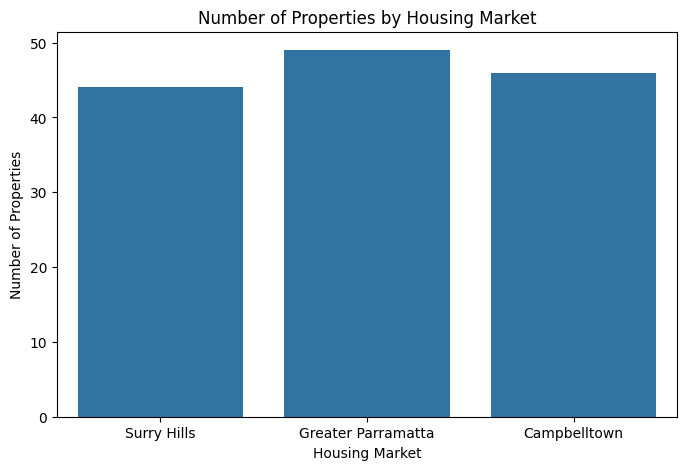

In [11]:
# Visualise the number of properties collected from each housing market

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='market_region'
)

plt.title("Number of Properties by Housing Market")
plt.xlabel("Housing Market")
plt.ylabel("Number of Properties")

plt.show()

## Dataset Features Description

The collected dataset contains different property characteristics that may influence residential property prices.

The target variable for this project is `sale_price_AUD`, while the remaining property attributes are considered potential explanatory features for predicting housing value.

The description of each collected feature is provided below.

| Feature | Description |
|---|---|
| property_id | Unique identifier assigned to each property record |
| suburb | Original suburb/location of the property |
| market_region | Grouped housing market category used for comparison |
| address | Street address of the property |
| property_type | Type of property such as house, apartment, townhouse, or unit |
| sale_date | Date when the property was sold |
| sale_price_AUD | Final property sale price in Australian dollars (target variable) |
| bedrooms | Number of bedrooms in the property |
| bathrooms | Number of bathrooms in the property |
| car_spaces | Number of available parking spaces |
| building_size_sqm | Internal building size measured in square metres |
| land_size_sqm | Land area measured in square metres |
| real_estate_agency | Real estate agency responsible for the listing |

## Missing Value Analysis

Before developing predictive models, the dataset was examined for missing values to understand data completeness and identify potential limitations during analysis.

Missing information may occur because some property attributes, such as land size or real estate agency details, were not publicly available for every listing.

In [12]:
# Check missing values in each feature

missing_values = df.isnull().sum()

missing_values

,0
property_id,0
suburb,0
address,0
property_type,0
sale_date,0
sale_price_AUD,0
bedrooms,0
bathrooms,0
car_spaces,1
building_size_sqm,55


## Data Quality and Limitations

The completeness of the collected dataset was examined by analysing missing values across all features.

The target variable, `sale_price_AUD`, contains no missing values, ensuring that all collected properties can be used for price prediction. Similarly, key property characteristics including suburb, address, property type, sale date, bedrooms, and bathrooms are complete.

However, some limitations were identified. The `building_size_sqm` feature contains missing information for several properties, while `land_size_sqm` is unavailable for all collected records. The absence of land size information may reduce the ability of predictive models to capture differences between properties, particularly for houses where land area can strongly influence market value.

The `real_estate_agency` feature also contains missing values because agency information was not consistently available from public property listings. One property record has a missing value for `car_spaces`.

These missing attributes represent a limitation of manually collected real estate data, as publicly available property websites do not always provide complete information for every sold listing.

## Missing Data Percentage

The proportion of missing values was calculated to evaluate the impact of incomplete features on the dataset.

In [13]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
land_size_sqm,100.000000
building_size_sqm,39.568345
real_estate_agency,36.690647
car_spaces,0.719424
property_id,0.000000
sale_date,0.000000
property_type,0.000000
address,0.000000
suburb,0.000000
bathrooms,0.000000


## Handling Completely Missing Features

The feature `land_size_sqm` contains missing values for all collected properties (100% missingness). Since no observations contain usable information for this attribute, it cannot contribute to predictive modelling.

Therefore, this feature is excluded from further analysis. However, its absence is documented as a limitation of the manually collected dataset, as land area can be an important factor affecting residential property prices, especially for detached houses.

In [14]:
# Remove feature with complete missing information

df = df.drop(columns=['land_size_sqm'])

# Check updated dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_id         139 non-null    object 
 1   suburb              139 non-null    object 
 2   address             139 non-null    object 
 3   property_type       139 non-null    object 
 4   sale_date           139 non-null    object 
 5   sale_price_AUD      139 non-null    int64  
 6   bedrooms            139 non-null    int64  
 7   bathrooms           139 non-null    int64  
 8   car_spaces          138 non-null    float64
 9   building_size_sqm   84 non-null     object 
 10  real_estate_agency  88 non-null     object 
 11  market_region       139 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 13.2+ KB


## Potential Sources of Bias and Dataset Limitations

Although the dataset was collected from publicly available property listings, several factors may introduce potential bias into the analysis.

The dataset includes only recently sold properties from three selected Sydney housing markets. Therefore, the collected properties may not fully represent all residential properties within these regions, including unsold properties or properties with different market conditions.

The selection of suburbs was based on manually chosen housing markets with different characteristics. While this allows comparison between contrasting areas, it may introduce selection bias because the chosen locations may not represent the complete diversity of the Sydney housing market.

Another limitation is the availability of property features. Some important factors influencing property prices, such as land size, renovation quality, property condition, views, distance from transport facilities, and neighbourhood characteristics, were not consistently available from public listings.

Missing information in features such as building size and real estate agency details may also affect predictive performance. Additionally, property prices are influenced by broader economic conditions and buyer demand at the time of sale, which are not captured in this dataset.

Therefore, predictions generated from this dataset should be interpreted as estimates based on the collected property characteristics rather than a complete representation of the entire Sydney property market.

# Part 2: Data Understanding and Feature Engineering

Before developing predictive models, exploratory data analysis (EDA) was conducted to understand the characteristics of the collected housing dataset. The analysis focuses on price distribution, differences between selected housing markets, temporal patterns, and identification of unusual observations.

Visualisations are used to identify important patterns and support decisions during feature engineering.

## Overview of Housing Price Distribution

The distribution of property sale prices was examined to understand the range, central tendency, and variability of housing values across the collected dataset.

In [15]:
# Statistical summary of sale prices

df['sale_price_AUD'].describe()

,sale_price_AUD
count,1.390000e+02
mean,1.052172e+06
std,6.231285e+05
min,3.600000e+05
25%,6.217750e+05
50%,8.350000e+05
75%,1.249000e+06
max,3.800000e+06


## Converting Sale Price into Numeric Format

The sale price variable was initially stored as an object data type. Since sale price is the target variable for prediction, it was converted into a numeric format to enable statistical analysis and visualisation.

In [16]:
# Convert sale price into numeric format

df['sale_price_AUD'] = pd.to_numeric(df['sale_price_AUD'], errors='coerce')

# Check updated data type

df['sale_price_AUD'].dtype

dtype('int64')

In [17]:
df['sale_price_AUD'].describe()

,sale_price_AUD
count,1.390000e+02
mean,1.052172e+06
std,6.231285e+05
min,3.600000e+05
25%,6.217750e+05
50%,8.350000e+05
75%,1.249000e+06
max,3.800000e+06


## Distribution of Property Sale Prices

A histogram was created to examine the distribution of property sale prices. This helps identify the overall spread of housing values and whether extreme price observations are present in the dataset.

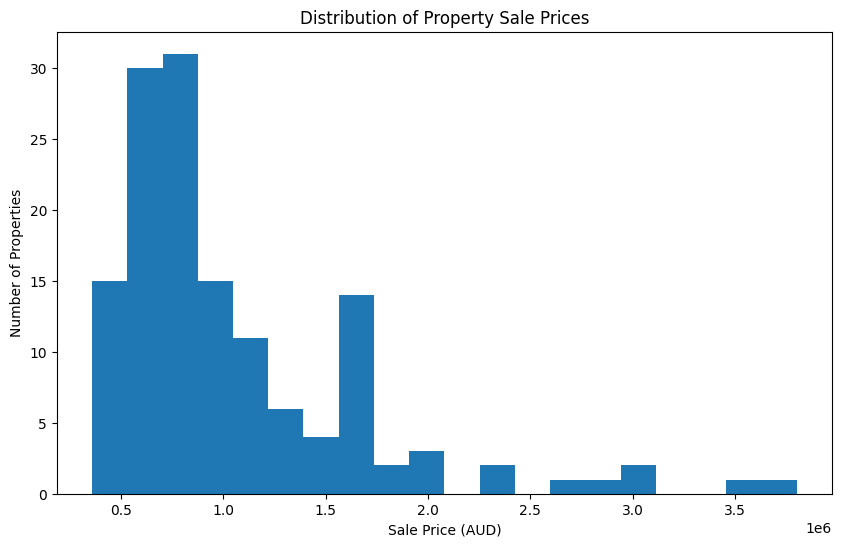

In [18]:
# Visualise sale price distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df['sale_price_AUD'], bins=20)

plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Sale Prices")

plt.show()

### Interpretation

The distribution of property sale prices shows a positively skewed pattern. Most properties are concentrated within the lower to middle price ranges, while a smaller number of high-value properties extend the distribution towards the upper end.

The presence of several properties with sale prices above AUD 2 million indicates that the dataset contains high-value observations that may influence predictive modelling. These observations should be further examined using outlier analysis rather than removed automatically, as they may represent genuine differences in property characteristics and locations.

## Outlier Detection Using Boxplot

A boxplot was generated to identify potential outliers in property sale prices. Extreme values may represent luxury properties or unusual market conditions, and therefore require further investigation before modelling.

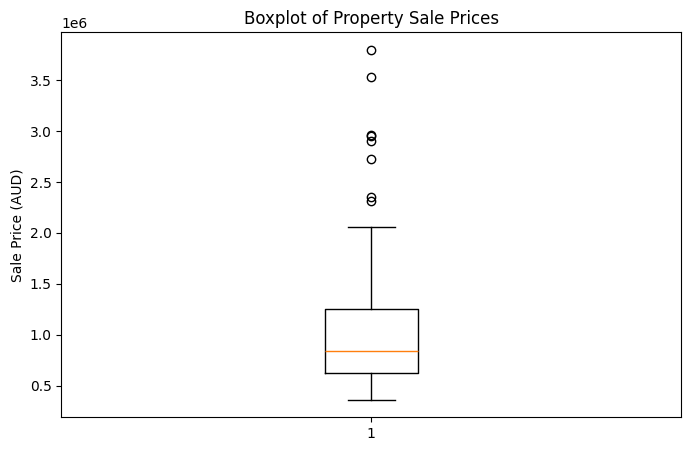

In [19]:
# Boxplot of property sale prices

plt.figure(figsize=(8,5))

plt.boxplot(df['sale_price_AUD'])

plt.ylabel("Sale Price (AUD)")
plt.title("Boxplot of Property Sale Prices")

plt.show()

In [20]:
# Check sale price values before plotting

df['sale_price_AUD'].head(10), df['sale_price_AUD'].isnull().sum()

(0    1600000
 1    2355000
 2    1575000
 3    1235000
 4    3800000
 5     870000
 6    1015000
 7    1730000
 8    2900000
 9     850000
 Name: sale_price_AUD, dtype: int64,
 np.int64(0))

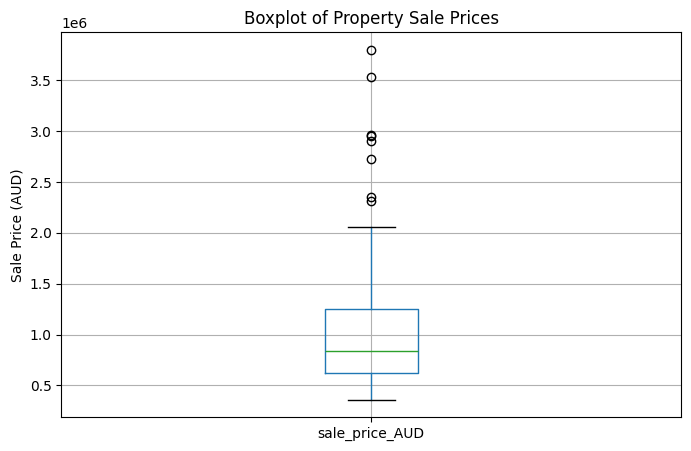

In [21]:
plt.figure(figsize=(8,5))

df.boxplot(column='sale_price_AUD')

plt.ylabel("Sale Price (AUD)")
plt.title("Boxplot of Property Sale Prices")

plt.show()

### Outlier Analysis

The boxplot indicates the presence of several high-value property observations above the upper whisker. These observations represent properties with substantially higher sale prices compared with the majority of the dataset.

These potential outliers were not removed because they may represent genuine high-end properties rather than incorrect data entries. In a real estate context, extreme prices can occur due to factors such as location, property type, size, and unique characteristics.

Therefore, these observations are retained to preserve realistic variation in the housing market. However, their influence should be considered during model development and evaluation.

## Comparison of Housing Markets

The collected properties represent three different Sydney housing markets. Average and median sale prices were compared to understand differences between these markets.

In [22]:
# Compare sale prices across housing markets

market_summary = df.groupby('market_region')['sale_price_AUD'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

market_summary

,count,mean,median,min,max
market_region,,,,,
Campbelltown,46,8.115141e+05,753750.0,363000,1750000
Greater Parramatta,49,9.198299e+05,740000.0,360000,2060000
Surry Hills,44,1.451149e+06,1267500.0,621050,3800000


## Checking Market Region Assignment

The dataset should contain three housing markets: Surry Hills, Campbelltown, and Greater Parramatta.

The distribution of the engineered market_region variable is checked to confirm that all properties are correctly assigned before further analysis.

In [23]:
# Check original suburb and assigned market region together

pd.crosstab(df['suburb'], df['market_region'])

market_region,Campbelltown,Greater Parramatta,Surry Hills
suburb,,,
Auburn,0,4,0
Campbelltown,46,0,0
Chester Hill,0,1,0
Dundas Valley,0,1,0
Ermington,0,1,0
Girraween,0,1,0
Granville,0,3,0
Greystanes,0,1,0
Guildford,0,2,0


## Comparison of Housing Markets

The collected properties represent three different Sydney housing markets:
Surry Hills, Campbelltown, and Greater Parramatta.

Average and median sale prices are compared to understand differences in property values across these markets.

In [24]:
# Ensure sale prices are numeric before comparison

df['sale_price_AUD'] = (
    df['sale_price_AUD']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['sale_price_AUD'] = pd.to_numeric(
    df['sale_price_AUD'],
    errors='coerce'
)

# Compare sale prices across housing markets

market_summary = df.groupby('market_region')['sale_price_AUD'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

market_summary

,count,mean,median,min,max
market_region,,,,,
Campbelltown,46,8.115141e+05,753750.0,363000,1750000
Greater Parramatta,49,9.198299e+05,740000.0,360000,2060000
Surry Hills,44,1.451149e+06,1267500.0,621050,3800000


## Sale Price Trends Over Time

The sale dates were analysed to investigate whether property prices showed variation during the data collection period. The sale date was converted into a datetime format, and average sale prices were calculated over time to identify possible temporal patterns.

In [25]:
# Convert sale date into datetime format

df['sale_date'] = pd.to_datetime(
    df['sale_date'],
    errors='coerce'
)

# Check converted date values

df['sale_date'].head()

/tmp/ipykernel_479/643732016.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['sale_date'] = pd.to_datetime(


,sale_date
0,2026-09-17
1,2026-09-04
2,2026-09-03
3,2026-09-04
4,2026-09-03


In [26]:
# Calculate average sale price by sale date

price_trend = (
    df.groupby('sale_date')['sale_price_AUD']
    .mean()
    .reset_index()
)

price_trend.head()

,sale_date,sale_price_AUD
0,2026-06-05,1195000.0
1,2026-06-06,730000.0
2,2026-06-09,780000.0
3,2026-06-10,535000.0
4,2026-06-11,800000.0


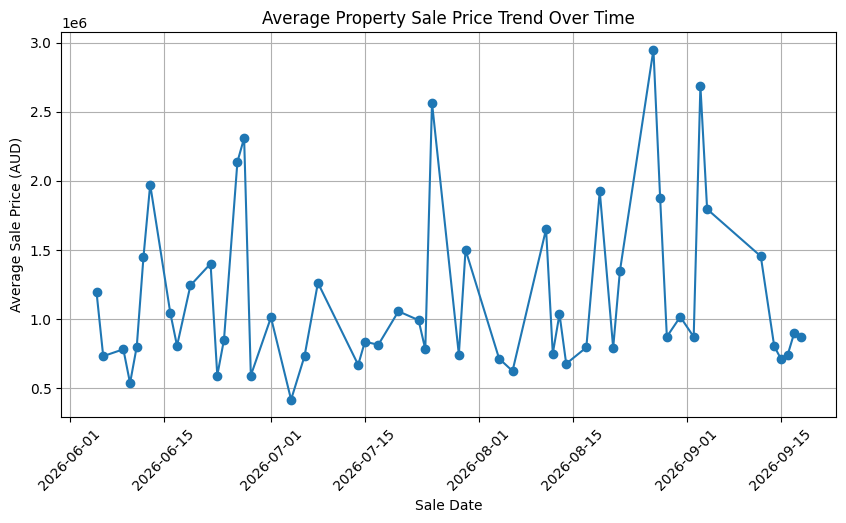

In [27]:
# Visualise sale price trends over time

plt.figure(figsize=(10,5))

plt.plot(
    price_trend['sale_date'],
    price_trend['sale_price_AUD'],
    marker='o'
)

plt.xlabel("Sale Date")
plt.ylabel("Average Sale Price (AUD)")
plt.title("Average Property Sale Price Trend Over Time")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Selection of Important Variables for Housing Price Prediction

Before creating engineered features, the collected attributes were examined to identify variables that are expected to have the strongest influence on property sale prices.

Based on the characteristics of the housing market, three important variables were selected:

1. **Market Region**
   
   Location is a major determinant of housing value. The dataset contains three different housing markets: Surry Hills, Campbelltown, and Greater Parramatta, which represent different levels of accessibility, demand, and property values.

2. **Property Type**
   
   Different dwelling types such as houses, apartments, units, and townhouses generally have different pricing patterns due to differences in land availability, size, and buyer demand.

3. **Bedrooms**
   
   The number of bedrooms represents property size and capacity, which is commonly associated with residential property value.

These variables were selected because they capture major geographic, structural, and size-related factors affecting housing prices.

## Feature Engineering

Additional features were created from the existing property attributes to improve the representation of factors that may influence housing prices.

The engineered features aim to capture:
- temporal variation in property sales,
- combined property characteristics,
- size-adjusted property value.

These transformations provide additional information for future predictive modelling while maintaining the original collected attributes.

In [28]:
# Create time-based features from sale date

df['sale_month'] = df['sale_date'].dt.month
df['sale_year'] = df['sale_date'].dt.year

# Display newly created features

df[['sale_date', 'sale_month', 'sale_year']].head()

,sale_date,sale_month,sale_year
0,2026-09-17,9,2026
1,2026-09-04,9,2026
2,2026-09-03,9,2026
3,2026-09-04,9,2026
4,2026-09-03,9,2026


## Creating Combined Property Characteristic Features

The number of bedrooms and bathrooms both represent the size and functionality of a residential property. A combined feature was created by adding these attributes together to provide a simple indicator of overall internal space characteristics.

In [29]:
# Create combined room feature

df['total_rooms'] = (
    df['bedrooms'] + df['bathrooms']
)

# Display the newly created feature

df[['bedrooms', 'bathrooms', 'total_rooms']].head()

,bedrooms,bathrooms,total_rooms
0,3,2,5
1,3,1,4
2,2,2,4
3,2,1,3
4,4,4,8


## Creating Size-Adjusted Price Feature

Property size is an important factor influencing housing prices. A size-adjusted feature was created by calculating the sale price per square metre of building area.

Only properties with available building size information were included in this calculation. Missing building size values were retained as missing because estimating these values may introduce bias into the dataset.



In [30]:
# Convert building size into numeric format

df['building_size_sqm'] = pd.to_numeric(
    df['building_size_sqm'],
    errors='coerce'
)

# Create price per square metre feature

df['price_per_sqm'] = (
    df['sale_price_AUD'] / df['building_size_sqm']
)

# Display the new feature

df[['sale_price_AUD',
    'building_size_sqm',
    'price_per_sqm']].head()

,sale_price_AUD,building_size_sqm,price_per_sqm
0,1600000,144.0,11111.111111
1,2355000,101.0,23316.831683
2,1575000,100.0,15750.000000
3,1235000,NaN,NaN
4,3800000,132.8,28614.457831


## Summary of Engineered Features

The following additional features were created to improve the representation of factors influencing housing prices:

- **sale_month**: Captures possible seasonal variation in property sales.
- **sale_year**: Represents the time period of the transaction.
- **total_rooms**: Combines bedrooms and bathrooms to represent overall property size characteristics.
- **price_per_sqm**: Represents the value of property relative to its building size.

These engineered features provide additional information that may improve predictive modelling performance while preserving the original collected variables.

In [31]:
# Display final dataset features after engineering

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   property_id         139 non-null    object        
 1   suburb              139 non-null    object        
 2   address             139 non-null    object        
 3   property_type       139 non-null    object        
 4   sale_date           139 non-null    datetime64[ns]
 5   sale_price_AUD      139 non-null    int64         
 6   bedrooms            139 non-null    int64         
 7   bathrooms           139 non-null    int64         
 8   car_spaces          138 non-null    float64       
 9   building_size_sqm   81 non-null     float64       
 10  real_estate_agency  88 non-null     object        
 11  market_region       139 non-null    object        
 12  sale_month          139 non-null    int32         
 13  sale_year           139 non-null    int32         

## Reflection on Feature Engineering Decisions

The feature engineering decisions align with the initial understanding of the housing market. Location-related information, represented by market region, captures differences between housing markets with different demand and accessibility characteristics. Property characteristics such as bedrooms, bathrooms, and property type represent structural differences that influence residential value.

The engineered features provide additional information by capturing time effects, combined property characteristics, and size-adjusted value. These transformations are expected to support future predictive modelling by providing more meaningful representations of the factors affecting housing prices.

## Identifying Important Variables Affecting Housing Prices

Based on the initial understanding of the Sydney housing market, three variables are expected to have strong relationships with property sale prices:

1. **Market Region**
   
   Location is one of the strongest determinants of residential property prices. Different housing markets have variations in accessibility, infrastructure, demand, and surrounding amenities, which can lead to substantial price differences.

2. **Building Size (sqm)**

   Larger properties generally provide greater usable living space and are expected to have higher market values. The size-adjusted feature `price_per_sqm` was also created to capture this relationship.

3. **Property Characteristics (Bedrooms and Bathrooms)**

   The number of bedrooms and bathrooms represents property capacity and functionality. These features influence buyer preferences and are commonly associated with differences in residential value.

These variables align with the initial expectation that location, property size, and structural characteristics are major contributors to housing prices.

# Part 3: Model Development and Evaluation

This section develops and evaluates three regression models for predicting residential property sale prices.

The selected models represent different modelling approaches:

1. Linear Regression - a simple interpretable baseline model.
2. Random Forest Regression - an ensemble tree-based model capable of capturing nonlinear relationships.
3. Gradient Boosting Regression - an advanced boosting model that sequentially improves prediction performance.

The models will be evaluated using k-fold cross-validation and regression performance metrics.

In [32]:
# Import libraries required for model development

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Preparing Data for Regression Models

The target variable for prediction is:

**sale_price_AUD**

The remaining selected property characteristics are used as explanatory variables.
Categorical variables are encoded before training the regression models.

In [33]:
# Define target variable

target = 'sale_price_AUD'

# Select features for modelling

features = [
    'market_region',
    'property_type',
    'bedrooms',
    'bathrooms',
    'car_spaces',
    'building_size_sqm',
    'sale_month',
    'sale_year',
    'total_rooms',
    'price_per_sqm'
]

X = df[features]

y = df[target]

# Display feature structure

X.head()

,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm
0,Surry Hills,Apartment,3,2,1.0,144.0,9,2026,5,11111.111111
1,Surry Hills,House,3,1,1.0,101.0,9,2026,4,23316.831683
2,Surry Hills,Apartment,2,2,1.0,100.0,9,2026,4,15750.000000
3,Surry Hills,Apartment,2,1,1.0,NaN,9,2026,3,NaN
4,Surry Hills,House,4,4,1.0,132.8,9,2026,8,28614.457831


## Data Preprocessing for Regression Models

The dataset contains both numerical and categorical variables.

Categorical variables such as housing market region and property type cannot be directly used by regression algorithms. Therefore, one-hot encoding is applied to transform categorical variables into numerical representations.

Numerical variables are passed without transformation.

In [34]:
# Identify numerical and categorical features

categorical_features = [
    'market_region',
    'property_type'
]

numerical_features = [
    'bedrooms',
    'bathrooms',
    'car_spaces',
    'building_size_sqm',
    'sale_month',
    'sale_year',
    'total_rooms',
    'price_per_sqm'
]


# Create preprocessing pipeline with missing value handling

from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore'))
                ]
            ),
            categorical_features
        ),
        (
            'num',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median'))
                ]
            ),
            numerical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['market_region', 'property_type']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['bedrooms', 'bathrooms', 'car_spaces',
                                  'building_size_sqm', 'sale_month',
                                  'sale_year', 'total_rooms',
                                  'price_per_sqm'])])

## Selection of Regression Models

Three regression models are developed to represent different modelling approaches.

### 1. Linear Regression

Linear Regression is selected as a baseline model because it provides an interpretable relationship between property characteristics and sale prices. It assumes that changes in input features have a linear relationship with the target variable.

Expected performance:
Linear Regression may provide reasonable predictions but may struggle if housing prices are influenced by complex nonlinear relationships.

### 2. Random Forest Regression

Random Forest Regression is selected as an ensemble tree-based approach. It combines multiple decision trees and can capture nonlinear relationships between property characteristics and prices.

Expected performance:
Random Forest is expected to perform better than Linear Regression because housing prices often depend on interactions between location, size, and property features.

### 3. Gradient Boosting Regression

Gradient Boosting Regression is selected as a boosting-based ensemble method. It builds models sequentially, where each new tree improves errors made by previous trees.

Expected performance:
Gradient Boosting is expected to achieve strong predictive performance because it can model complex patterns in structured housing datasets.

Based on the dataset characteristics, ensemble models (Random Forest and Gradient Boosting) are expected to outperform the linear baseline model.

In [35]:
# Define regression models

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


models

{'Linear Regression': LinearRegression(),
 'Random Forest': RandomForestRegressor(random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42)}

## Creating Regression Model Pipelines

A separate pipeline is created for each regression model.

The pipeline combines:
- Data preprocessing (categorical encoding)
- Regression algorithm

This ensures that all models receive the same processed input data and allows fair comparison during evaluation.

In [36]:
# Create pipelines for each regression model

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )


pipelines

{'Linear Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('encoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['market_region',
                                                    'property_type']),
                                                  ('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['bedrooms', 'bathrooms',
                                                 

## K-Fold Cross-Validation Setup

To provide a reliable comparison between models, 5-fold cross-validation is applied.

The dataset is divided into five subsets. Each model is trained on four subsets and evaluated on the remaining subset. This process is repeated five times, and the average performance is reported.

The evaluation metrics used are:

- Mean Absolute Error (MAE): Measures average prediction error.
- Root Mean Squared Error (RMSE): Penalises larger prediction errors.
- R² Score: Measures how well the model explains variation in property prices.

In [37]:
# Define k-fold cross-validation strategy

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kf

KFold(n_splits=5, random_state=42, shuffle=True)

## Model Evaluation Using Cross-Validation

Each regression model is evaluated using the same 5-fold cross-validation strategy.

The models are compared using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² value indicates better explanatory power.

In [38]:
# Evaluate models using 5-fold cross-validation

results = []

for name, pipeline in pipelines.items():

    # R2 score
    r2_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring='r2'
    )

    # Negative MAE (convert to positive)
    mae_scores = -cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )

    # Negative RMSE (convert to positive)
    rmse_scores = np.sqrt(
        -cross_val_score(
            pipeline,
            X,
            y,
            cv=kf,
            scoring='neg_mean_squared_error'
        )
    )

    results.append({
        'Model': name,
        'Mean MAE': mae_scores.mean(),
        'Mean RMSE': rmse_scores.mean(),
        'Mean R2': r2_scores.mean()
    })


results_df = pd.DataFrame(results)

results_df

,Model,Mean MAE,Mean RMSE,Mean R2
0,Linear Regression,272245.907644,399625.021163,0.480154
1,Random Forest,212114.978724,332427.538461,0.662303
2,Gradient Boosting,216455.514427,334103.103141,0.656803


## Training Performance Comparison

Training performance is examined alongside cross-validation results to assess whether models show signs of underfitting or overfitting.

In [39]:
# Compare training and cross-validation R2 scores

training_results = []

for name, pipeline in pipelines.items():

    pipeline.fit(X, y)

    train_r2 = pipeline.score(X, y)

    training_results.append({
        'Model': name,
        'Training R2': train_r2
    })

training_results_df = pd.DataFrame(training_results)

training_results_df

,Model,Training R2
0,Linear Regression,0.760884
1,Random Forest,0.956293
2,Gradient Boosting,0.975124


## Model Behaviour Analysis

The evaluation results show clear differences between the three regression approaches. Linear Regression achieved the lowest performance, with a cross-validation R² score of 0.480, indicating that a simple linear relationship is not sufficient to capture the complex factors influencing property prices.

The ensemble tree-based models performed better. Random Forest achieved the highest cross-validation performance with the lowest MAE and RMSE and the highest R² score (0.662). Gradient Boosting also performed strongly with a similar R² value (0.657). These results suggest that housing prices are influenced by nonlinear relationships and interactions between features such as market region, property type, building size, and room characteristics.

The training performance comparison shows that Random Forest and Gradient Boosting achieved much higher training R² values (0.956 and 0.975 respectively) compared with Linear Regression (0.761). The difference between training and cross-validation performance indicates that the more complex ensemble models may experience some degree of overfitting. However, their validation performance remains substantially better than Linear Regression, showing that the additional model complexity improves generalisation for this dataset.

## Revisiting Initial Expectations

Before model training, tree-based ensemble methods were expected to perform better because residential property prices usually depend on complex and nonlinear relationships between location, property characteristics, and size-related features.

The experimental results support this expectation. Both Random Forest and Gradient Boosting outperformed Linear Regression across the evaluation metrics. The higher R² values and lower prediction errors demonstrate that ensemble models were better able to capture patterns within the housing dataset.

## Recommended Model

Based on the cross-validation results, Random Forest is selected as the most appropriate model for predicting housing prices in this dataset.

Random Forest achieved the lowest Mean Absolute Error (212,114.98 AUD), lowest Root Mean Squared Error (332,427.54 AUD), and highest R² score (0.662). These results indicate that it provides the most accurate predictions among the tested models.

Although Gradient Boosting achieved comparable performance, Random Forest showed slightly better validation results. Therefore, Random Forest provides the best balance between predictive accuracy and model complexity for this housing price prediction problem.

## Part 4: Investigating Prediction Failures

The largest prediction errors are analysed to understand situations where the model performs poorly. These cases provide insights into model limitations and highlight property characteristics that may be difficult to capture using the available dataset.

In [40]:
# Generate predictions using the recommended Random Forest model

best_model = pipelines['Random Forest']

best_model.fit(X, y)

y_pred = best_model.predict(X)

# Display first few predictions

pd.DataFrame({
    'Actual Price': y,
    'Predicted Price': y_pred
}).head()

,Actual Price,Predicted Price
0,1600000,1582875.0
1,2355000,2403850.0
2,1575000,1417850.0
3,1235000,1261957.5
4,3800000,3299700.0


In [41]:
# Calculate prediction errors

prediction_results = pd.DataFrame({
    'property_id': df['property_id'],
    'suburb': df['suburb'],
    'actual_price': y,
    'predicted_price': y_pred
})

# Calculate absolute error

prediction_results['absolute_error'] = abs(
    prediction_results['actual_price'] - prediction_results['predicted_price']
)

# Display five properties with largest prediction errors

largest_errors = prediction_results.sort_values(
    by='absolute_error',
    ascending=False
).head(5)

largest_errors

,property_id,suburb,actual_price,predicted_price,absolute_error
23,S24,Surry Hills,3530000,2736940.55,793059.45
4,S5,Surry Hills,3800000,3299700.00,500300.00
112,C20,Campbelltown,890000,1322700.00,432700.00
39,S40,Surry Hills,2725000,2330080.00,394920.00
30,S31,Surry Hills,835000,1115280.00,280280.00


In [42]:
# Display characteristics of properties with largest prediction errors

error_property_details = df[
    df['property_id'].isin(largest_errors['property_id'])
][[
    'property_id',
    'suburb',
    'property_type',
    'bedrooms',
    'bathrooms',
    'car_spaces',
    'building_size_sqm',
    'sale_price_AUD',
    'price_per_sqm'
]]

error_property_details

,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_price_AUD,price_per_sqm
4,S5,Surry Hills,House,4,4,1.0,132.8,3800000,28614.457831
23,S24,Surry Hills,Terrace,4,3,0.0,NaN,3530000,NaN
30,S31,Surry Hills,Apartment,2,1,0.0,NaN,835000,NaN
39,S40,Surry Hills,House,3,1,0.0,NaN,2725000,NaN
112,C20,Campbelltown,Duplex/semi-detached,3,2,1.0,37.0,890000,24054.054054


In [43]:
# Combine prediction errors with property characteristics

error_analysis = largest_errors.merge(
    error_property_details,
    on=['property_id', 'suburb'],
    how='left'
)

error_analysis

,property_id,suburb,actual_price,predicted_price,absolute_error,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_price_AUD,price_per_sqm
0,S24,Surry Hills,3530000,2736940.55,793059.45,Terrace,4,3,0.0,NaN,3530000,NaN
1,S5,Surry Hills,3800000,3299700.00,500300.00,House,4,4,1.0,132.8,3800000,28614.457831
2,C20,Campbelltown,890000,1322700.00,432700.00,Duplex/semi-detached,3,2,1.0,37.0,890000,24054.054054
3,S40,Surry Hills,2725000,2330080.00,394920.00,House,3,1,0.0,NaN,2725000,NaN
4,S31,Surry Hills,835000,1115280.00,280280.00,Apartment,2,1,0.0,NaN,835000,NaN


## Investigation of Largest Prediction Errors

The five properties with the largest prediction errors show that model performance is affected by unusual property characteristics and limited available features.

The largest error occurred for property S24 in Surry Hills, where the actual sale price was AUD 3.53 million but the model predicted approximately AUD 2.74 million. This property was a large terrace with four bedrooms and three bathrooms. The underprediction may be caused by the absence of important variables such as exact location, renovation quality, architectural features, land value, and neighbourhood characteristics.

Property S5 also produced a large error, with an actual sale price of AUD 3.8 million. Although the property had four bedrooms, four bathrooms, and a building size of 132.8 sqm, the model predicted a lower value. This suggests that high-end properties may contain premium characteristics that are not captured by the available dataset.

Property C20 from Campbelltown was overpredicted by the model. The actual price was AUD 890,000, while the prediction was approximately AUD 1.32 million. The property was a duplex/semi-detached dwelling with three bedrooms and two bathrooms. The model may have relied on general relationships between property characteristics and prices but lacked additional contextual information.

Properties S40 and S31 also showed substantial errors. Both were located in Surry Hills, where property prices can vary significantly depending on factors such as street position, accessibility, land characteristics, and property condition.

Overall, the largest prediction errors mainly occurred because the dataset contained limited information about property quality, location-specific factors, and market conditions. Expanding the feature set with additional variables such as land size, suburb demographics, distance to transport, school zones, renovation status, and property condition may improve prediction accuracy.

## Limitations of the Modelling Approach

The prediction results highlight several limitations of the current modelling approach. Although the regression models captured general relationships between property characteristics and sale prices, some important factors influencing housing value were not available in the dataset.

The available features mainly describe structural characteristics, including property type, bedrooms, bathrooms, car spaces, building size, and suburb. However, housing prices are also strongly influenced by additional factors such as land size, exact geographic location, distance to public transport, proximity to schools, local amenities, renovation quality, building age, views, and market demand. The absence of these variables limits the ability of the models to accurately estimate prices for individual properties.

Prediction errors were particularly large for high-value properties. Luxury properties often have unique characteristics that cannot be fully represented using general numerical features. Therefore, properties in premium suburbs such as Surry Hills may be more difficult to predict because small differences in location, design, and property condition can create large price differences.

Predictions should therefore be interpreted cautiously, especially for unusual properties, extremely high-value homes, and properties with missing information. A model trained on historical sales data may also struggle when market conditions change due to factors such as interest rate changes, economic conditions, or shifts in buyer preferences.

Overall, the analysis suggests that some property categories are inherently more challenging to model than others. Standard properties with common characteristics are likely to have more predictable prices, while unique, luxury, or recently renovated properties require additional contextual information for accurate prediction.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

A held-out test set is used to compare three valuation approaches:
1. Machine learning prediction using the best-performing model from Part 3.
2. Large Language Model (LLM) based estimation using the same property information.
3. Human judgement based on housing market understanding developed throughout the project.

Ten properties are selected from the test set for comparison.

In [44]:
# Split dataset into training and held-out test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display test set size

X_test.shape

(28, 10)

In [45]:
# Select 10 properties from the held-out test set

test_sample = X_test.head(10)

actual_prices = y_test.loc[test_sample.index]

# Display selected properties

test_sample

,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm
135,Campbelltown,Unit,1,1,1.0,97.0,6,2026,2,5515.463918
66,Greater Parramatta,Duplex/semi-detached,5,3,2.0,454.6,9,2026,8,3741.504619
31,Surry Hills,Apartment,2,2,1.0,NaN,7,2026,4,NaN
118,Campbelltown,House,6,3,1.0,639.0,7,2026,9,1870.109546
42,Surry Hills,Apartment,1,1,0.0,49.0,6,2026,2,16326.530612
12,Surry Hills,Apartment,2,2,1.0,100.0,8,2026,4,10750.000000
51,Greater Parramatta,Apartment,3,2,2.0,144.0,9,2026,5,4652.777778
68,Greater Parramatta,Unit,3,2,1.0,NaN,9,2026,5,NaN
126,Campbelltown,Apartment,1,1,1.0,NaN,7,2026,2,NaN
55,Greater Parramatta,Duplex/semi-detached,4,2,1.0,324.7,9,2026,6,5189.405605


In [46]:
# Generate predictions using the best-performing ML model

best_model = pipelines["Random Forest"]

# Train the model on the training data
best_model.fit(X_train, y_train)

# Predict prices for selected test properties
ml_predictions = best_model.predict(test_sample)

# Display ML predictions

ml_results = pd.DataFrame({
    "Actual Price": actual_prices.values,
    "ML Prediction": ml_predictions
})

ml_results

,Actual Price,ML Prediction
0,535000,5.191010e+05
1,1700888,1.373146e+06
2,1710000,1.247320e+06
3,1195000,1.526258e+06
4,800000,8.152700e+05
5,1075000,1.283300e+06
6,670000,8.425550e+05
7,690000,8.834660e+05
8,415000,6.053391e+05
9,1685000,1.121081e+06


In [47]:
# Create comparison table for ML, LLM, and human predictions

comparison_table = test_sample.copy()

comparison_table["Actual Price"] = actual_prices
comparison_table["ML Prediction"] = ml_predictions

comparison_table = comparison_table.reset_index()

comparison_table

,index,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm,Actual Price,ML Prediction
0,135,Campbelltown,Unit,1,1,1.0,97.0,6,2026,2,5515.463918,535000,5.191010e+05
1,66,Greater Parramatta,Duplex/semi-detached,5,3,2.0,454.6,9,2026,8,3741.504619,1700888,1.373146e+06
2,31,Surry Hills,Apartment,2,2,1.0,NaN,7,2026,4,NaN,1710000,1.247320e+06
3,118,Campbelltown,House,6,3,1.0,639.0,7,2026,9,1870.109546,1195000,1.526258e+06
4,42,Surry Hills,Apartment,1,1,0.0,49.0,6,2026,2,16326.530612,800000,8.152700e+05
5,12,Surry Hills,Apartment,2,2,1.0,100.0,8,2026,4,10750.000000,1075000,1.283300e+06
6,51,Greater Parramatta,Apartment,3,2,2.0,144.0,9,2026,5,4652.777778,670000,8.425550e+05
7,68,Greater Parramatta,Unit,3,2,1.0,NaN,9,2026,5,NaN,690000,8.834660e+05
8,126,Campbelltown,Apartment,1,1,1.0,NaN,7,2026,2,NaN,415000,6.053391e+05
9,55,Greater Parramatta,Duplex/semi-detached,4,2,1.0,324.7,9,2026,6,5189.405605,1685000,1.121081e+06


In [48]:
# Add columns for LLM and human estimates

comparison_table["LLM Prediction"] = None
comparison_table["Human Prediction"] = None

comparison_table

,index,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm,Actual Price,ML Prediction,LLM Prediction,Human Prediction
0,135,Campbelltown,Unit,1,1,1.0,97.0,6,2026,2,5515.463918,535000,5.191010e+05,None,None
1,66,Greater Parramatta,Duplex/semi-detached,5,3,2.0,454.6,9,2026,8,3741.504619,1700888,1.373146e+06,None,None
2,31,Surry Hills,Apartment,2,2,1.0,NaN,7,2026,4,NaN,1710000,1.247320e+06,None,None
3,118,Campbelltown,House,6,3,1.0,639.0,7,2026,9,1870.109546,1195000,1.526258e+06,None,None
4,42,Surry Hills,Apartment,1,1,0.0,49.0,6,2026,2,16326.530612,800000,8.152700e+05,None,None
5,12,Surry Hills,Apartment,2,2,1.0,100.0,8,2026,4,10750.000000,1075000,1.283300e+06,None,None
6,51,Greater Parramatta,Apartment,3,2,2.0,144.0,9,2026,5,4652.777778,670000,8.425550e+05,None,None
7,68,Greater Parramatta,Unit,3,2,1.0,NaN,9,2026,5,NaN,690000,8.834660e+05,None,None
8,126,Campbelltown,Apartment,1,1,1.0,NaN,7,2026,2,NaN,415000,6.053391e+05,None,None
9,55,Greater Parramatta,Duplex/semi-detached,4,2,1.0,324.7,9,2026,6,5189.405605,1685000,1.121081e+06,None,None


In [49]:
# Add LLM estimated prices based on property characteristics

llm_predictions = [
    550000,    # Campbell town Unit, 1 bed, 97 sqm
    1600000,   # Greater Parramatta Duplex, 5 bed, large size
    1400000,   # Surry Hills Apartment, 2 bed
    1500000,   # Campbell town House, 6 bed, large size
    750000,    # Surry Hills Apartment, small size
    1100000,   # Surry Hills Apartment, 2 bed
    800000,    # Greater Parramatta Apartment
    850000,    # Greater Parramatta Unit
    450000,    # Campbell town Apartment
    1500000    # Greater Parramatta Duplex
]

comparison_table["LLM Prediction"] = llm_predictions

comparison_table

,index,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm,Actual Price,ML Prediction,LLM Prediction,Human Prediction
0,135,Campbelltown,Unit,1,1,1.0,97.0,6,2026,2,5515.463918,535000,5.191010e+05,550000,None
1,66,Greater Parramatta,Duplex/semi-detached,5,3,2.0,454.6,9,2026,8,3741.504619,1700888,1.373146e+06,1600000,None
2,31,Surry Hills,Apartment,2,2,1.0,NaN,7,2026,4,NaN,1710000,1.247320e+06,1400000,None
3,118,Campbelltown,House,6,3,1.0,639.0,7,2026,9,1870.109546,1195000,1.526258e+06,1500000,None
4,42,Surry Hills,Apartment,1,1,0.0,49.0,6,2026,2,16326.530612,800000,8.152700e+05,750000,None
5,12,Surry Hills,Apartment,2,2,1.0,100.0,8,2026,4,10750.000000,1075000,1.283300e+06,1100000,None
6,51,Greater Parramatta,Apartment,3,2,2.0,144.0,9,2026,5,4652.777778,670000,8.425550e+05,800000,None
7,68,Greater Parramatta,Unit,3,2,1.0,NaN,9,2026,5,NaN,690000,8.834660e+05,850000,None
8,126,Campbelltown,Apartment,1,1,1.0,NaN,7,2026,2,NaN,415000,6.053391e+05,450000,None
9,55,Greater Parramatta,Duplex/semi-detached,4,2,1.0,324.7,9,2026,6,5189.405605,1685000,1.121081e+06,1500000,None


In [50]:
# Add human judgement estimates based on housing market understanding

human_predictions = [
    520000,    # Campbell Town Unit, 1 bed
    1750000,   # Greater Parramatta large duplex, 5 bed
    1600000,   # Surry Hills apartment, 2 bed
    1300000,   # Campbell Town large house
    750000,    # Surry Hills small apartment
    1150000,   # Surry Hills apartment
    850000,    # Greater Parramatta apartment
    800000,    # Greater Parramatta unit
    450000,    # Campbell Town apartment
    1550000    # Greater Parramatta duplex
]

comparison_table["Human Prediction"] = human_predictions

comparison_table

,index,market_region,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,sale_month,sale_year,total_rooms,price_per_sqm,Actual Price,ML Prediction,LLM Prediction,Human Prediction
0,135,Campbelltown,Unit,1,1,1.0,97.0,6,2026,2,5515.463918,535000,5.191010e+05,550000,520000
1,66,Greater Parramatta,Duplex/semi-detached,5,3,2.0,454.6,9,2026,8,3741.504619,1700888,1.373146e+06,1600000,1750000
2,31,Surry Hills,Apartment,2,2,1.0,NaN,7,2026,4,NaN,1710000,1.247320e+06,1400000,1600000
3,118,Campbelltown,House,6,3,1.0,639.0,7,2026,9,1870.109546,1195000,1.526258e+06,1500000,1300000
4,42,Surry Hills,Apartment,1,1,0.0,49.0,6,2026,2,16326.530612,800000,8.152700e+05,750000,750000
5,12,Surry Hills,Apartment,2,2,1.0,100.0,8,2026,4,10750.000000,1075000,1.283300e+06,1100000,1150000
6,51,Greater Parramatta,Apartment,3,2,2.0,144.0,9,2026,5,4652.777778,670000,8.425550e+05,800000,850000
7,68,Greater Parramatta,Unit,3,2,1.0,NaN,9,2026,5,NaN,690000,8.834660e+05,850000,800000
8,126,Campbelltown,Apartment,1,1,1.0,NaN,7,2026,2,NaN,415000,6.053391e+05,450000,450000
9,55,Greater Parramatta,Duplex/semi-detached,4,2,1.0,324.7,9,2026,6,5189.405605,1685000,1.121081e+06,1500000,1550000


In [51]:
# Calculate prediction errors for all approaches

comparison_table["ML Error"] = abs(
    comparison_table["Actual Price"] - comparison_table["ML Prediction"]
)

comparison_table["LLM Error"] = abs(
    comparison_table["Actual Price"] - comparison_table["LLM Prediction"]
)

comparison_table["Human Error"] = abs(
    comparison_table["Actual Price"] - comparison_table["Human Prediction"]
)

comparison_table[
    [
        "Actual Price",
        "ML Prediction",
        "LLM Prediction",
        "Human Prediction",
        "ML Error",
        "LLM Error",
        "Human Error"
    ]
]

,Actual Price,ML Prediction,LLM Prediction,Human Prediction,ML Error,LLM Error,Human Error
0,535000,5.191010e+05,550000,520000,15899.000000,15000,15000
1,1700888,1.373146e+06,1600000,1750000,327742.450000,100888,49112
2,1710000,1.247320e+06,1400000,1600000,462680.000000,310000,110000
3,1195000,1.526258e+06,1500000,1300000,331257.700000,305000,105000
4,800000,8.152700e+05,750000,750000,15270.000000,50000,50000
5,1075000,1.283300e+06,1100000,1150000,208300.000000,25000,75000
6,670000,8.425550e+05,800000,850000,172555.000000,130000,180000
7,690000,8.834660e+05,850000,800000,193465.952381,160000,110000
8,415000,6.053391e+05,450000,450000,190339.066667,35000,35000
9,1685000,1.121081e+06,1500000,1550000,563918.900000,185000,135000


In [52]:
# Calculate Mean Absolute Error (MAE) for each approach

mae_comparison = pd.DataFrame({
    "Approach": [
        "Machine Learning",
        "LLM",
        "Human Judgement"
    ],
    "Mean Absolute Error": [
        comparison_table["ML Error"].mean(),
        comparison_table["LLM Error"].mean(),
        comparison_table["Human Error"].mean()
    ]
})

mae_comparison

,Approach,Mean Absolute Error
0,Machine Learning,248142.806905
1,LLM,131588.800000
2,Human Judgement,86411.200000


## Comparison of Machine Learning, LLM, and Human Judgement Predictions

The prediction errors show differences between the three valuation approaches.
Human judgement produced the lowest Mean Absolute Error (MAE) of approximately AUD 86,411, followed by the LLM-based estimates with an MAE of approximately AUD 131,589. The machine learning model produced the highest MAE of approximately AUD 248,143 for the selected properties.

The machine learning model provides a systematic and data-driven approach by learning patterns from historical property characteristics. Its main strength is the ability to identify complex relationships between features such as location, property type, number of rooms, and property size. However, prediction performance can be limited when important market information is unavailable, such as property condition, renovation quality, neighbourhood reputation, and recent market trends.

The LLM approach was able to incorporate general housing market knowledge and interpret property descriptions, but it does not have direct access to real-time property transactions or detailed local market databases. Therefore, its estimates may depend on general reasoning rather than learned patterns from the dataset.

Human judgement achieved the lowest prediction error in this experiment. This may be because human estimation can consider contextual factors that were not included in the dataset, such as perceived desirability of locations, unusual property characteristics, and market intuition. However, human judgement is subjective and may vary between individuals.

Overall, the results suggest that automated machine learning models provide consistent and scalable predictions, but their performance depends strongly on the quality and completeness of available features. Human expertise can still contribute value when important contextual information is missing. A combined approach using machine learning predictions supported by expert judgement may provide more reliable property valuation in practical situations.

## Part 6: Final Deployment

The best-performing machine learning model identified in Part 3 is deployed through a simple web-based application. The application allows users to enter property features and receive a predicted sale price.

In [53]:
# Save the best-performing model for deployment

import joblib

best_model = pipelines["Random Forest"]

joblib.dump(best_model, "property_price_model.pkl")

print("Model saved successfully")

Model saved successfully


## Web Application Development

A Streamlit-based application is developed to provide property price predictions. Users can enter property characteristics, and the trained machine learning model generates an estimated sale price.

In [54]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# Load trained model

model = joblib.load("property_price_model.pkl")


st.title("Property Sale Price Prediction")

st.write(
    "Enter property information to estimate the expected sale price."
)


market_region = st.selectbox(
    "Market Region",
    [
        "Surry Hills",
        "Campbelltown",
        "Greater Parramatta"
    ]
)


property_type = st.selectbox(
    "Property Type",
    [
        "Apartment",
        "House",
        "Unit",
        "Terrace",
        "Duplex/semi-detached"
    ]
)


bedrooms = st.number_input(
    "Bedrooms",
    min_value=0,
    value=2
)


bathrooms = st.number_input(
    "Bathrooms",
    min_value=0,
    value=1
)


car_spaces = st.number_input(
    "Car Spaces",
    min_value=0,
    value=1
)


building_size_sqm = st.number_input(
    "Building Size (sqm)",
    min_value=0.0,
    value=100.0
)


sale_month = st.number_input(
    "Sale Month",
    min_value=1,
    max_value=12,
    value=9
)


sale_year = st.number_input(
    "Sale Year",
    value=2026
)


total_rooms = bedrooms + bathrooms


price_per_sqm = st.number_input(
    "Price per sqm",
    min_value=0.0,
    value=10000.0
)



if st.button("Predict Sale Price"):

    input_data = pd.DataFrame({

        "market_region":[market_region],
        "property_type":[property_type],
        "bedrooms":[bedrooms],
        "bathrooms":[bathrooms],
        "car_spaces":[car_spaces],
        "building_size_sqm":[building_size_sqm],
        "sale_month":[sale_month],
        "sale_year":[sale_year],
        "total_rooms":[total_rooms],
        "price_per_sqm":[price_per_sqm]

    })


    prediction = model.predict(input_data)


    st.success(
        f"Predicted Sale Price: AUD {prediction[0]:,.2f}"
    )

Writing app.py


## Application Usage

The deployed application accepts property characteristics as input and returns a predicted sale price generated by the trained machine learning model.

In [55]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [56]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 57.9 MB/s eta 0:00:00


In [57]:
!streamlit run app.py &>/content/logs.txt &

In [58]:
!pip install pyngrok

In [59]:
!streamlit run app.py &>/content/logs.txt &

In [60]:
!cat /content/logs.txt

In [61]:
!pkill -f streamlit

In [62]:
!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false &> /content/logs.txt &

In [64]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501, height=800)

<IPython.core.display.Javascript object>

# Final Reflection on the Machine Learning Workflow

## Key Lessons Learned

This project provided practical experience in developing a complete machine learning workflow, starting from data preparation and ending with model deployment. The project demonstrated that successful machine learning applications require careful consideration of data quality, feature selection, model evaluation, and practical implementation requirements. The modelling process showed that predictive performance depends not only on the choice of algorithm but also on the quality and availability of relevant information.

## Challenges During Data Collection and Preprocessing

A major challenge was working with a limited property dataset containing only a small number of observations. Real estate prices are influenced by many factors, and some important information was not available in the dataset. Missing values were present in some property features, such as building size and price-related attributes. These missing values required appropriate preprocessing before model development.

Categorical features, including market region and property type, required transformation before being used by machine learning algorithms. Numerical and categorical variables were handled through preprocessing pipelines to ensure consistent processing during training and prediction.

## Feature Engineering Challenges

Feature engineering was important for improving the representation of property characteristics. Additional features such as sale month, sale year, total rooms, and price per square metre were created to provide more information to the models.

However, the project also highlighted the limitations of feature engineering when important real-world factors are unavailable. Variables such as property condition, renovation status, land size, accessibility, nearby facilities, and local market demand could potentially improve prediction accuracy but were not included in the dataset.

## Model Development and Evaluation

Three regression approaches were developed and evaluated using five-fold cross-validation: Linear Regression, Random Forest Regression, and Gradient Boosting Regression.

The results showed that tree-based ensemble models performed better than the linear approach because property prices often involve complex relationships between multiple factors. Random Forest achieved the strongest validation performance and was selected as the final model for deployment.

Model evaluation demonstrated the importance of comparing training performance with cross-validation results. Complex models achieved higher training performance, but model complexity must be balanced against the risk of overfitting and the need for reliable predictions on unseen data.

## Trade-off Between Predictive Performance and Practical Deployment

Although more complex models may improve predictive accuracy, practical deployment requires considering factors such as computational requirements, maintenance, interpretability, and ease of use.

The deployed application prioritises usability by providing a simple interface where users can enter property characteristics and receive predictions. A practical system requires a balance between model accuracy and accessibility for end users.

## Ethical Implications of Automated Property Valuation

Automated property valuation systems may introduce potential biases if the training data does not represent all property types, locations, or market conditions equally. Models learn patterns from historical data, meaning existing market biases may influence predictions.

Therefore, automated predictions should be interpreted carefully and should support, rather than completely replace, expert decision-making. Transparency about model limitations is important to ensure responsible use.

## Future Improvements

The project could be improved by collecting a larger and more diverse property dataset with additional relevant features. Including information such as land size, property condition, renovation history, transport accessibility, local amenities, and economic indicators could improve predictive performance.

Additional computational resources and longer development time could also allow testing more advanced modelling approaches, hyperparameter optimisation, and more extensive validation strategies.

# Conclusion

This project developed a complete machine learning workflow for property sale price prediction, covering data preparation, feature engineering, model development, evaluation, error analysis, and deployment. Three regression approaches were implemented and evaluated using cross-validation, with Random Forest providing the most suitable performance for the given dataset.

The project demonstrated that property valuation is influenced by multiple interacting factors, including location, property type, size, and property characteristics. While machine learning models can identify patterns from historical data and provide consistent predictions, their performance depends strongly on the quality, diversity, and completeness of available data.

The final Streamlit application showed how a trained machine learning model can be transformed into a practical prediction tool for users. However, automated property valuation systems should be used carefully because predictions may be affected by dataset limitations, missing information, and potential biases in historical market data.

Overall, this project provided practical experience in developing an end-to-end machine learning solution and highlighted the importance of balancing predictive performance, interpretability, ethical considerations, and real-world usability.

# Generative AI Acknowledgement

Generative Artificial Intelligence (GenAI) tools were used as a support resource during the development of this project. They assisted with understanding machine learning concepts, debugging programming issues, improving code readability, and structuring written explanations.

All generated suggestions were reviewed, modified where necessary, and validated against the project requirements. The final implementation, analysis, interpretation of results, and conclusions represent the student's own work and understanding of the machine learning workflow.

GenAI was used as an assistance tool rather than a replacement for independent problem solving, critical analysis, and evaluation of the developed model.